# Read training data of forcesmip6 challenge

In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

# Get Test data in Evaluation Tier1 

In [3]:
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Evaluation-Tier1/Amon/tas'
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_test[count,:,:,:] = np.array(netcdf_file.variables['tas'][:]) 
        for i in range(12):
            data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_test[count,:,:,:].shape}')
        
        count += 1


  Processing 6/81: tas_mon_1F.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc
  Tas shape: (876, 72, 144)


In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0 
for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # print(netcdf_file.variables)
        print(np.array(netcdf_file.variables['arr_EM']).shape)

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_ground_truth_test[count,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

        for i in range(12):
            data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_ground_truth_test[count,:,:,:].shape}')
        count += 1

  Processing 7: 1A.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)


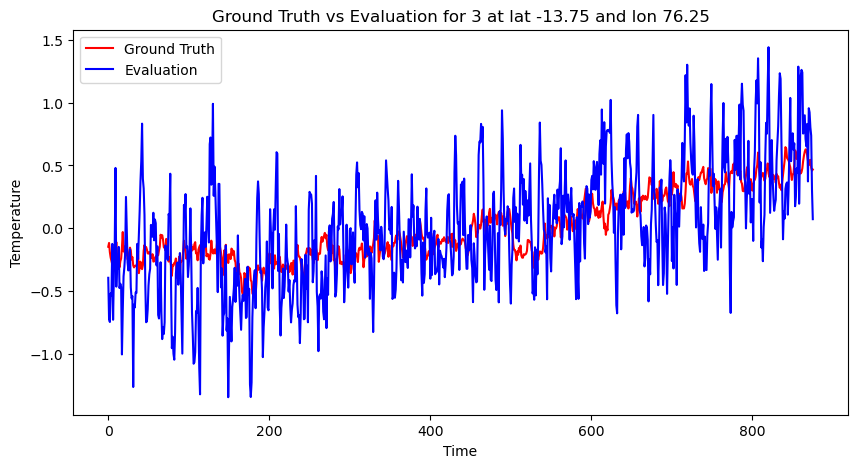

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 3
idx_lat = 30
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# Merge training data to train the ridge regression model

In [6]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


# Get the estimates of the other methods

In [9]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/submissions-Tier1-standardized-estimates'
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        data_estimates[:,count,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,count,:,:,:].shape}')
        count += 1



  Processing 51/80: tas_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc


  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.nc
  Tas shape: (30, 876, 72, 144)


In [10]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.56707537 0.51562512]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.65890628 0.57861054]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.66019011 0.61788714]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.45016742 0.56614858]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.47265992 0.4801116 ]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.43721801 0.3903268 ]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.4932439  0.40448675]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

# Yearly data

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

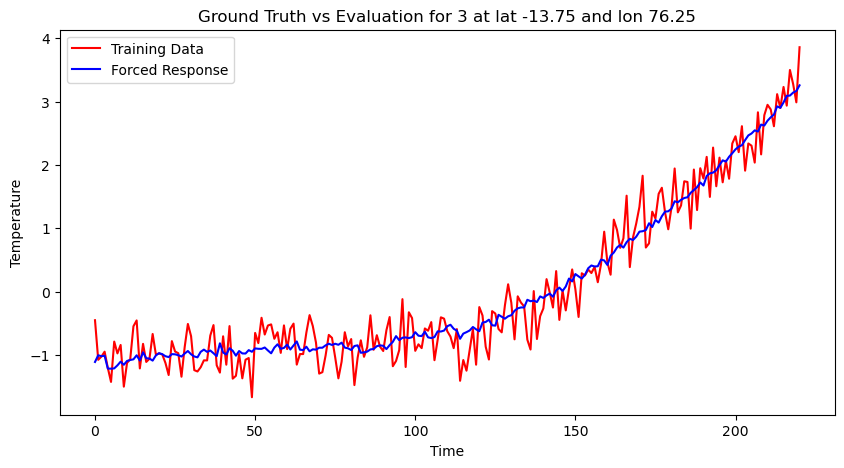

In [12]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [ ]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


# normalize the data
# dic_data_tmp = normalize_data(dic_data, means, vars)
# dic_forced_response_tmp = normalize_data(dic_forced_response, means, vars)

# dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
# dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for CESM2
Computing variance for CanESM5


Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [14]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


In [16]:
# add the spatial mean as a column of the training data
# x_train_yearly_new = x_train_yearly.x

In [ ]:
x_train_yearly_new = np.c_[x_train_yearly,np.zeros(x_train_yearly.shape[0])]
x_train_yearly_new[:,-1] = np.nanmean(x_train_yearly, axis=1)

y_train_yearly_new = np.c_[y_train_yearly,np.zeros(y_train_yearly.shape[0])]
y_train_yearly_new[:,-1] = np.nanmean(y_train_yearly, axis=1)


In [18]:
x_train_yearly_new = torch.from_numpy(x_train_yearly_new).to(torch.float32)
y_train_yearly_new = torch.from_numpy(y_train_yearly_new).to(torch.float32)

In [19]:
# from algorithms import train_trace_norm_ridge

# w_trace = train_trace_norm_ridge(x_train_yearly_tmp,y_train_yearly_tmp,lambda_=10000,nu_=5000.0,dtype=torch.float32,verbose=False)

In [20]:
from algorithms import ridge_regression, ridge_regression_low_rank
# proximal_algorithm_ridge_trace_penalty,train_trace_norm_ridge

# penalty parameters
lambda_tmp = 3000.0
rank = 15

# ridge regression
# w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)
w_ridge = ridge_regression(x_train_yearly_new, y_train_yearly_new, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)


# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly_new@w_ridge,full_matrices=False)

Loss function:  479789.75


In [21]:
rank = 2
w_ridge_low_rank = w_ridge @ V[:rank,:].T@V[:rank,:]


In [22]:
# Evaluate the model on test data
x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])
y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])

x_test_new = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]+1), dtype=torch.float32)
for i in range(x_test.shape[0]):
    x_test_new[i,:,:-1] = x_test[i,:,:]
    x_test_new[i,:,-1] = torch.nanmean(x_test[i,:,:], axis=1)

In [23]:
# preditcion on test data
y_pred_new = x_test_new @ w_ridge
y_pred_new_lr = x_test_new @ w_ridge_low_rank

rmse = torch.sqrt(torch.mean((y_pred_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_new_lr[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank}')

MSE Ridge Regression: [0.44320157 0.60636145 0.77299833 0.5214688  0.59804314 0.46664086
 0.5604301  0.3969463  0.5303736  0.59325695]
MSE Low Rank Ridge Regression: [0.41925147 0.5593888  0.7612498  0.49051312 0.5735552  0.43534946
 0.533139   0.37588212 0.49940217 0.56449157]


In [24]:
# Evaluate the model on test data
# x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])
# y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],longitude.shape[0]*latitude.shape[0])

# # Evaluate the model on test data
# y_pred = x_test @ w_ridge
# y_pred_low_rank = x_test @ w_ridge_low_rank
# # y_pred_trace = x_test @ w_trace


# # Compute the mean squared error
# rmse = torch.sqrt(torch.mean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
# rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test) ** 2,axis=(1,2))).detach().numpy()
# # rmse_trace = torch.sqrt(torch.mean((y_pred_trace - y_test) ** 2,axis=(1,2))).detach().numpy()

# print(f'  MSE: {rmse}')
# print(f'  MSE low rank: {rmse_low_rank}')
# print(f'  MSE trace norm: {rmse_trace}')

In [25]:
# compute residuals for each run of each model
# residuals = {}
# for idx_m, m in enumerate(dic_data.keys()):
#     # residuals[m] = np.zeros(dic_data[m].shape[0], dtype=np.float32)
#     # for idx_r in range(dic_data[m].shape[0]):
#     residuals[m] = np.nanmean((dic_data[m] - dic_forced_response[m])**2, axis=(1,2,3))

In [26]:
# # compute the residuals for the test data with respect to the mean of training data for each model
# residuals_test = {}
# for idx_m, m in enumerate(dic_data.keys()):
#     residuals_test[m] = np.nanmean((data_test - np.nanmean(dic_forced_response[m],axis=0))**2, axis=(1,2,3))

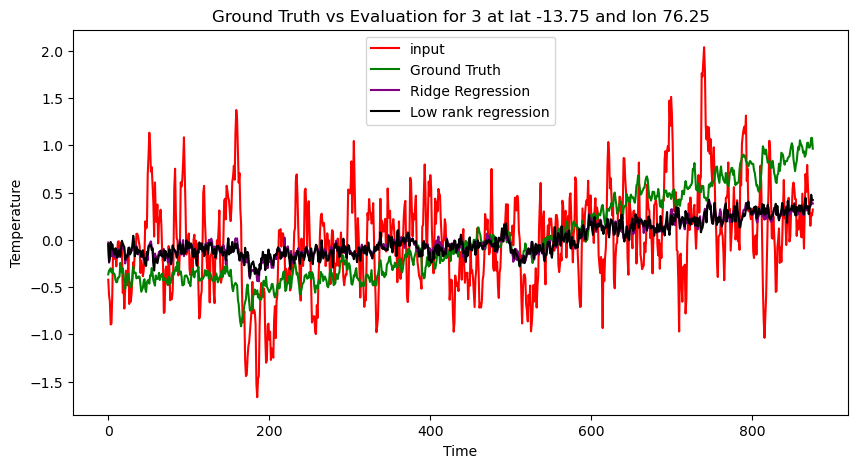

In [27]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
# plt.plot(dic_data['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(x_test.reshape(10,y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='input', color='red')
plt.plot(y_test.reshape(10,y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ground Truth', color='green')
plt.plot(y_pred_new[:,:,:-1].reshape(10,y_pred_new.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ridge Regression', color='purple')
plt.plot(y_pred_new_lr[:,:,:-1].reshape(10,y_pred_new_lr.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Low rank regression', color='black')
# plt.plot(y_pred_trace.reshape(10,y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Trace norm regression', color='orange')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [28]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['median'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['75th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['90th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['95th'] = np.zeros(mse_estimates.shape[0]+3)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates.shape[0]+3)

# compute also the variance of mse estimates
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+3)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)



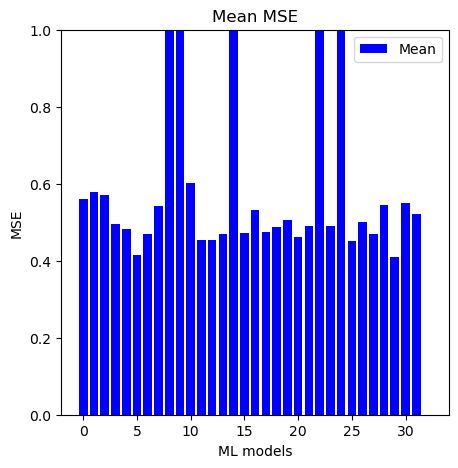

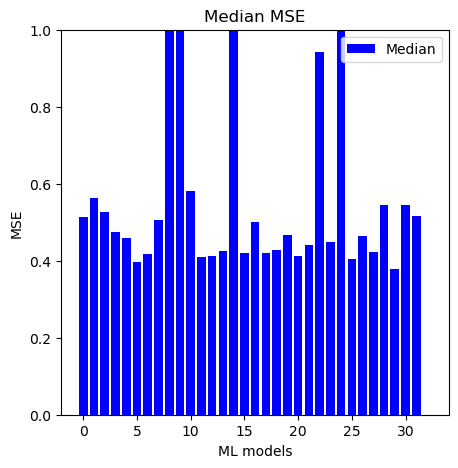

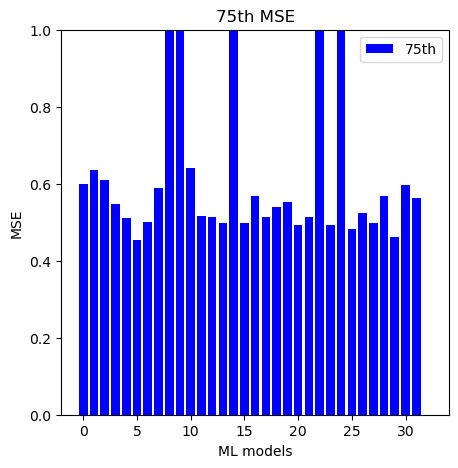

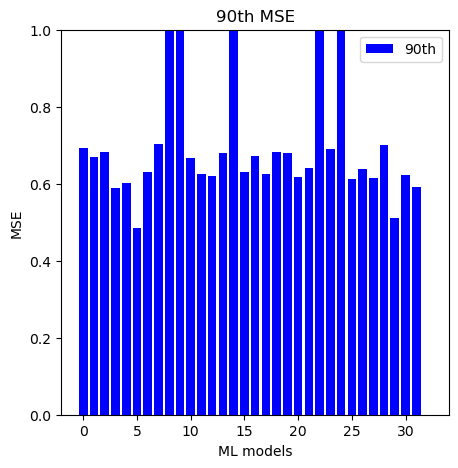

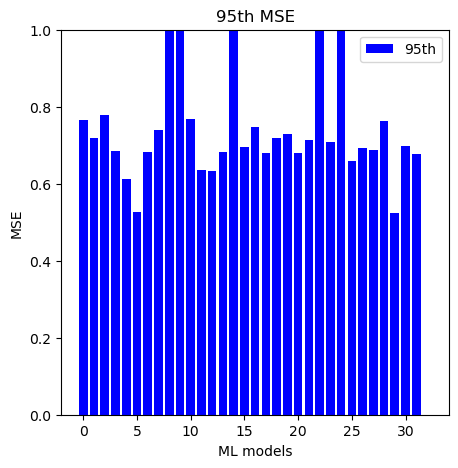

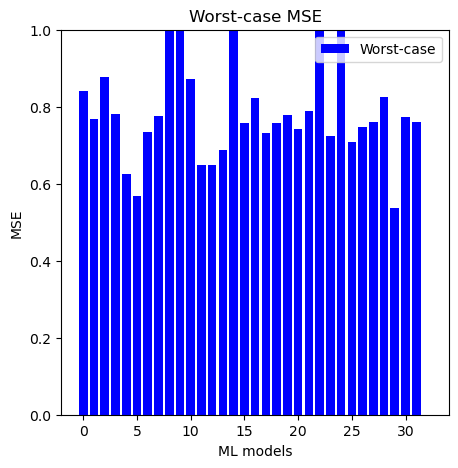

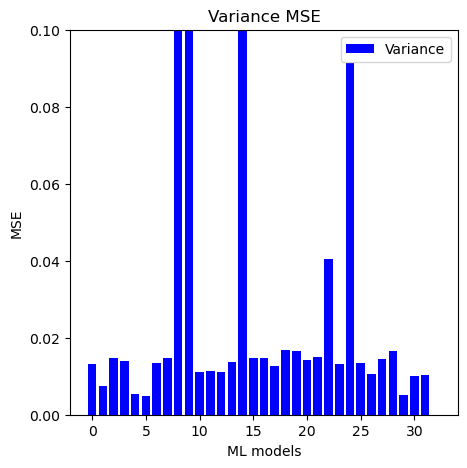

In [29]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

In [30]:
# create a laplacian matric of the spatial grid latitude x longitude
from scipy.sparse import diags
def create_laplacian_matrix(latitude, longitude):
    """
    Create a Laplacian matrix for the spatial grid.
    Args:
        latitude: numpy array of shape (n_latitude,)
        longitude: numpy array of shape (n_longitude,)
    Returns:
        Laplacian matrix of shape (n_latitude * n_longitude, n_latitude * n_longitude)
    """
    n_lat = latitude.shape[0]
    n_lon = longitude.shape[0]
    
    # Create the Laplacian matrix
    laplacian = np.zeros((n_lat * n_lon, n_lat * n_lon), dtype=np.float32)
    
    for i in range(n_lat):
        for j in range(n_lon):
            idx = i * n_lon + j
            laplacian[idx, idx] = -4  # center point
            
            if i > 0:  # north
                laplacian[idx, idx - n_lon] = 1
            if i < n_lat - 1:  # south
                laplacian[idx, idx + n_lon] = 1
            if j > 0:  # west
                laplacian[idx, idx - 1] = 1
            if j < n_lon - 1:  # east
                laplacian[idx, idx + 1] = 1
    
    return torch.from_numpy(laplacian).to(torch.float32)



In [31]:
def laplacian_ridge_regression(X, Y, latitude, longitude, lambda_=1.0, nu_=1.0,dtype=torch.float32,verbose=False):
    """
    Computes the closed-form solution for reduced rank regression.
    
    Args:
        X (torch.Tensor): Predictor matrix of shape (n, p).
        Y (torch.Tensor): Response matrix of shape (n, q).
        lambda_ (scalar): Ridge penalty coefficient.
        
    Returns:
        U (torch.Tensor): Low-rank predictor coefficients of shape (p, rank).
        V (torch.Tensor): Low-rank response coefficients of shape (q, rank).
    """
    
    L = create_laplacian_matrix(latitude, longitude)

    # compute Penroe Morose pseudo inverse of X^T @ X
    P = torch.linalg.inv((nu_* L + torch.eye(X.shape[1],dtype=dtype)) @ X.T @ X  + lambda_ * torch.eye(X.shape[1],dtype=dtype))
    
    # compute ordinary least square solution 
    W_ols = P @ X.T @ Y

    # print loss function 
    if verbose:
        loss = torch.norm(Y - X @ W_ols,p='fro')**2 + lambda_ * torch.norm(W_ols,p='fro')**2
        print("Loss function: ", loss.item())
    
    return W_ols

In [36]:
rmse

array([0.44320157, 0.60636145, 0.77299833, 0.5214688 , 0.59804314,
       0.46664086, 0.5604301 , 0.3969463 , 0.5303736 , 0.59325695],
      dtype=float32)

In [37]:
rmse_low_rank

array([0.41925147, 0.5593888 , 0.7612498 , 0.49051312, 0.5735552 ,
       0.43534946, 0.533139  , 0.37588212, 0.49940217, 0.56449157],
      dtype=float32)

In [42]:
from algorithms import laplacian_ridge_regression

lambda_tmp = 3000.0
nu_tmp = 0.1

# Train the model with Laplacian regularization
w_laplacian = laplacian_ridge_regression(x_train_yearly, y_train_yearly, latitude,longitude, lambda_=lambda_tmp, nu_=nu_tmp, verbose=True, dtype=torch.float32)


Loss function:  489875.375


In [43]:
# evaluate the model on test data
y_pred_laplacian = x_test @ w_laplacian

# Compute the mean squared error
rmse_laplacian = torch.sqrt(torch.mean((y_pred_laplacian - y_test) ** 2,axis=(1,2))).detach().numpy()
print(f'  MSE Laplacian Ridge Regression: {rmse_laplacian}')

  MSE Laplacian Ridge Regression: [0.44922835 0.6167834  0.7736688  0.5276232  0.601713   0.4722596
 0.5653065  0.4029679  0.53609854 0.6004987 ]
